In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'CS'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'CS',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.06,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '玉米淀粉'}

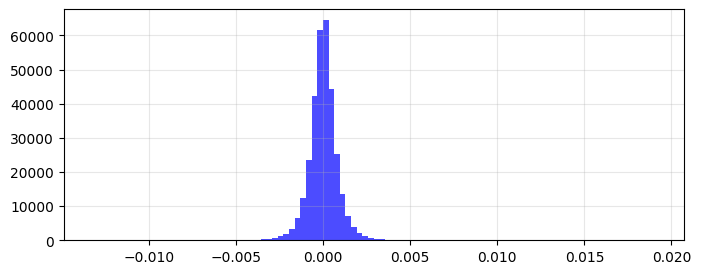

2025-07-01_CS_5


/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/miniconda3/lib/python3.13/site-pac

因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/group/2025-07-01_CS_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1792

特征重要性过滤： 300 200 	待筛因子个数 1792
无向因子有效个数： 907 有向因子有效个数： 927
  选择有向特征 189 个，重要性范围: 2145.00 - 72.00
  选择无向特征 145 个，重要性范围: 3493.00 - 131.00

单因子sharpe过滤： 0.5 sp范围-16.5896 ~ 15.5058   待筛因子个数 334

特征相关性性过滤： 300     待筛因子个数 284
  选择特征 247 个, 特征最大相关性0.8933912323227806

已挑选日频开盘因子数量： 5 ['day_first3power', 'day_first4redcorr', 'day_first10colarrate', 'day_jump', 'day_first10rev']

保留日频开盘因子数量： 5 ['day_first3power', 'day_first4redcorr', 'day_first10colarrate', 'day_jump', 'day_first10rev']

排除指定因子后，剩余特征 245 个


(169, 0, 50, 26)

正在从 /mnt/Data/writable/liaoyuyang/factor/CS/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (318166, 1889)
训练集时间范围: 2021-02-02 09:11:00 至 2025-06-30 22:49:00
[200]	valid_0's rmse: 0.995962
[400]	valid_0's rmse: 0.996086
[600]	valid_0's rmse: 0.996194


<Figure size 1000x600 with 0 Axes>

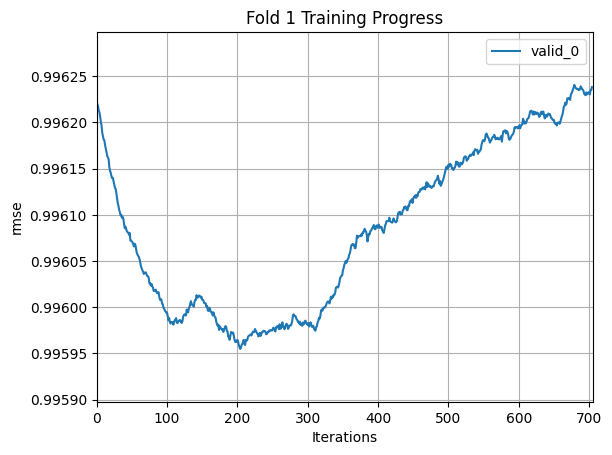

{'train_rmse': np.float64(0.99733472111545), 'val_rmse': np.float64(0.9997319094959055), 'best_iteration': 205}
test_corr: 0.0377
[200]	valid_0's rmse: 0.995642
[400]	valid_0's rmse: 0.99558
[600]	valid_0's rmse: 0.99562
[800]	valid_0's rmse: 0.995724


<Figure size 1000x600 with 0 Axes>

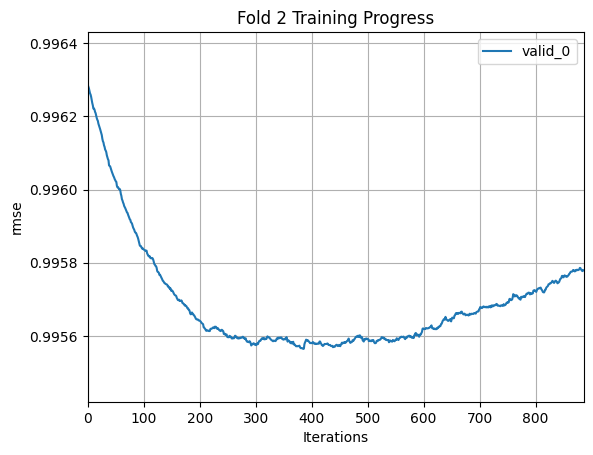

{'train_rmse': np.float64(0.9949990486473579), 'val_rmse': np.float64(0.9993531611482236), 'best_iteration': 386}
test_corr: 0.0272
[200]	valid_0's rmse: 0.995613
[400]	valid_0's rmse: 0.995363
[600]	valid_0's rmse: 0.995297
[800]	valid_0's rmse: 0.995295
[1000]	valid_0's rmse: 0.995284
[1200]	valid_0's rmse: 0.995298
[1400]	valid_0's rmse: 0.995369


<Figure size 1000x600 with 0 Axes>

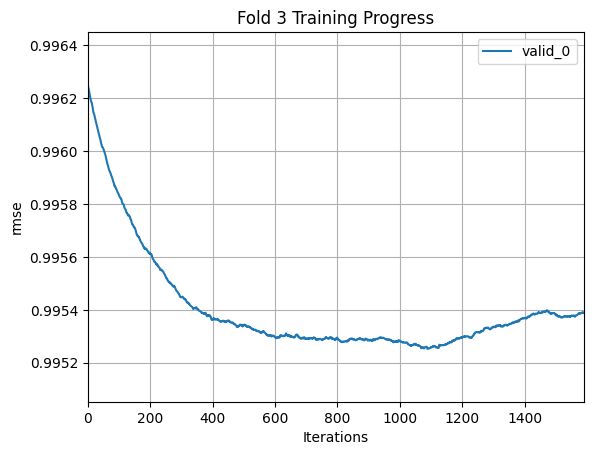

{'train_rmse': np.float64(0.9878055203206719), 'val_rmse': np.float64(0.9990521640690799), 'best_iteration': 1089}
test_corr: 0.0233
[200]	valid_0's rmse: 0.995833
[400]	valid_0's rmse: 0.995625
[600]	valid_0's rmse: 0.995508
[800]	valid_0's rmse: 0.995432
[1000]	valid_0's rmse: 0.995391
[1200]	valid_0's rmse: 0.99536
[1400]	valid_0's rmse: 0.995337
[1600]	valid_0's rmse: 0.995311
[1800]	valid_0's rmse: 0.99532
[2000]	valid_0's rmse: 0.995335


<Figure size 1000x600 with 0 Axes>

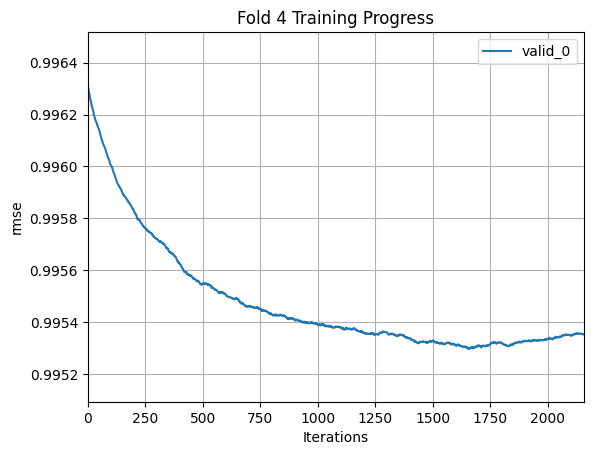

{'train_rmse': np.float64(0.9836897312589808), 'val_rmse': np.float64(0.9990715808164966), 'best_iteration': 1657}
test_corr: 0.0343
[200]	valid_0's rmse: 0.995894
[400]	valid_0's rmse: 0.995769
[600]	valid_0's rmse: 0.995822
[800]	valid_0's rmse: 0.995895


<Figure size 1000x600 with 0 Axes>

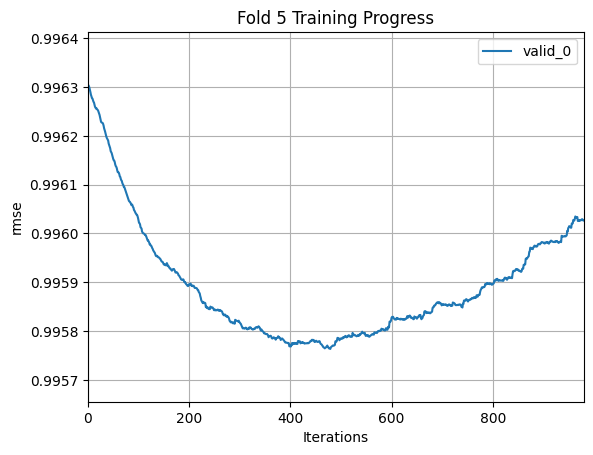

{'train_rmse': np.float64(0.9941492442818668), 'val_rmse': np.float64(0.9995397708508663), 'best_iteration': 480}
test_corr: 0.0267


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/CS_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-02 09:01:00,cs2105,3168.0,3168.0,3162.0,3163.0,3163.427536,3163.454203,560.0,17720100.0,...,1.239130,188,2021-02-02,3165.30,3164.586207,3162.793103,3163.148760,0.000593,-0.001046,-0.000165
1,2021-02-02 09:02:00,cs2105,3163.0,3163.0,3159.0,3160.0,3160.781955,3160.722255,577.0,18236340.0,...,1.090226,196,2021-02-02,3162.35,3162.111111,3161.400000,3160.547009,0.000008,-0.000881,-0.000513
2,2021-02-02 09:03:00,cs2105,3160.0,3163.0,3160.0,3163.0,3162.136000,3161.932330,244.0,7715560.0,...,1.080000,181,2021-02-02,3160.35,3160.730769,3161.958333,3162.422018,-0.000724,-0.000509,-0.000131
3,2021-02-02 09:04:00,cs2105,3163.0,3163.0,3161.0,3161.0,3162.448980,3162.383640,307.0,9708620.0,...,1.306122,161,2021-02-02,3162.95,3162.714286,3162.736842,3162.448276,-0.000783,0.000591,0.000040
4,2021-02-02 09:05:00,cs2105,3161.0,3161.0,3159.0,3160.0,3160.174242,3160.199242,320.0,10112690.0,...,1.204545,172,2021-02-02,3160.75,3160.750000,3160.550000,3160.160000,-0.000141,0.000957,0.000993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418780,2026-03-09 14:56:00,cs2605,2718.0,2720.0,2717.0,2718.0,2718.266010,2718.220692,667.0,18132500.0,...,1.019704,203,2026-03-09,2718.60,2718.638889,2719.000000,2718.256831,-0.000734,-0.001585,-0.001852
418781,2026-03-09 14:57:00,cs2605,2717.0,2718.0,2715.0,2716.0,2716.565714,2716.737672,310.0,8421990.0,...,1.000000,175,2026-03-09,2717.35,2717.192308,2717.384615,2716.493750,0.000762,-0.001821,-0.001285
418782,2026-03-09 14:58:00,cs2605,2715.0,2716.0,2713.0,2716.0,2714.649746,2714.901548,1087.0,29503250.0,...,1.050761,197,2026-03-09,2715.90,2715.605263,2715.241379,2714.500000,0.000052,-0.002402,-0.001576
418783,2026-03-09 14:59:00,cs2605,2716.0,2718.0,2716.0,2717.0,2716.507143,2716.770729,354.0,9617530.0,...,1.000000,140,2026-03-09,2716.15,2716.324324,2716.545455,2716.568966,-0.000582,-0.002347,-0.001803


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/52184 [00:00<?, ?it/s]

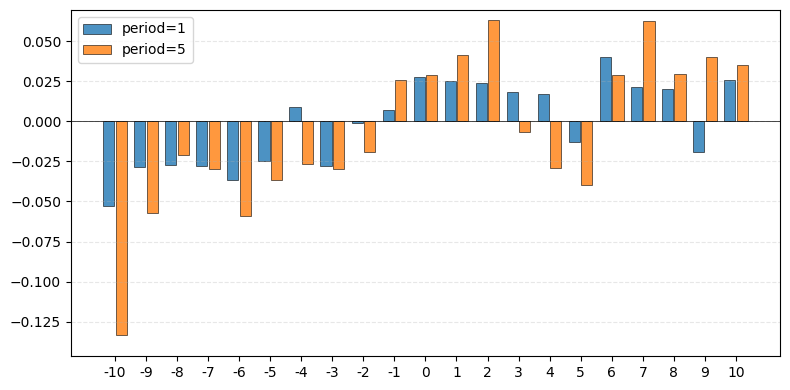

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,11912
空头(-1) 数量,8967
空仓(0) 数量,31307
多头占比,22.83%
空头占比,17.18%
空仓占比,59.99%
交易日数量,153
总收益(非年化%),2.24
总交易次数（开平算一次）,3110
日均交易次数（开平算一次）,20.33


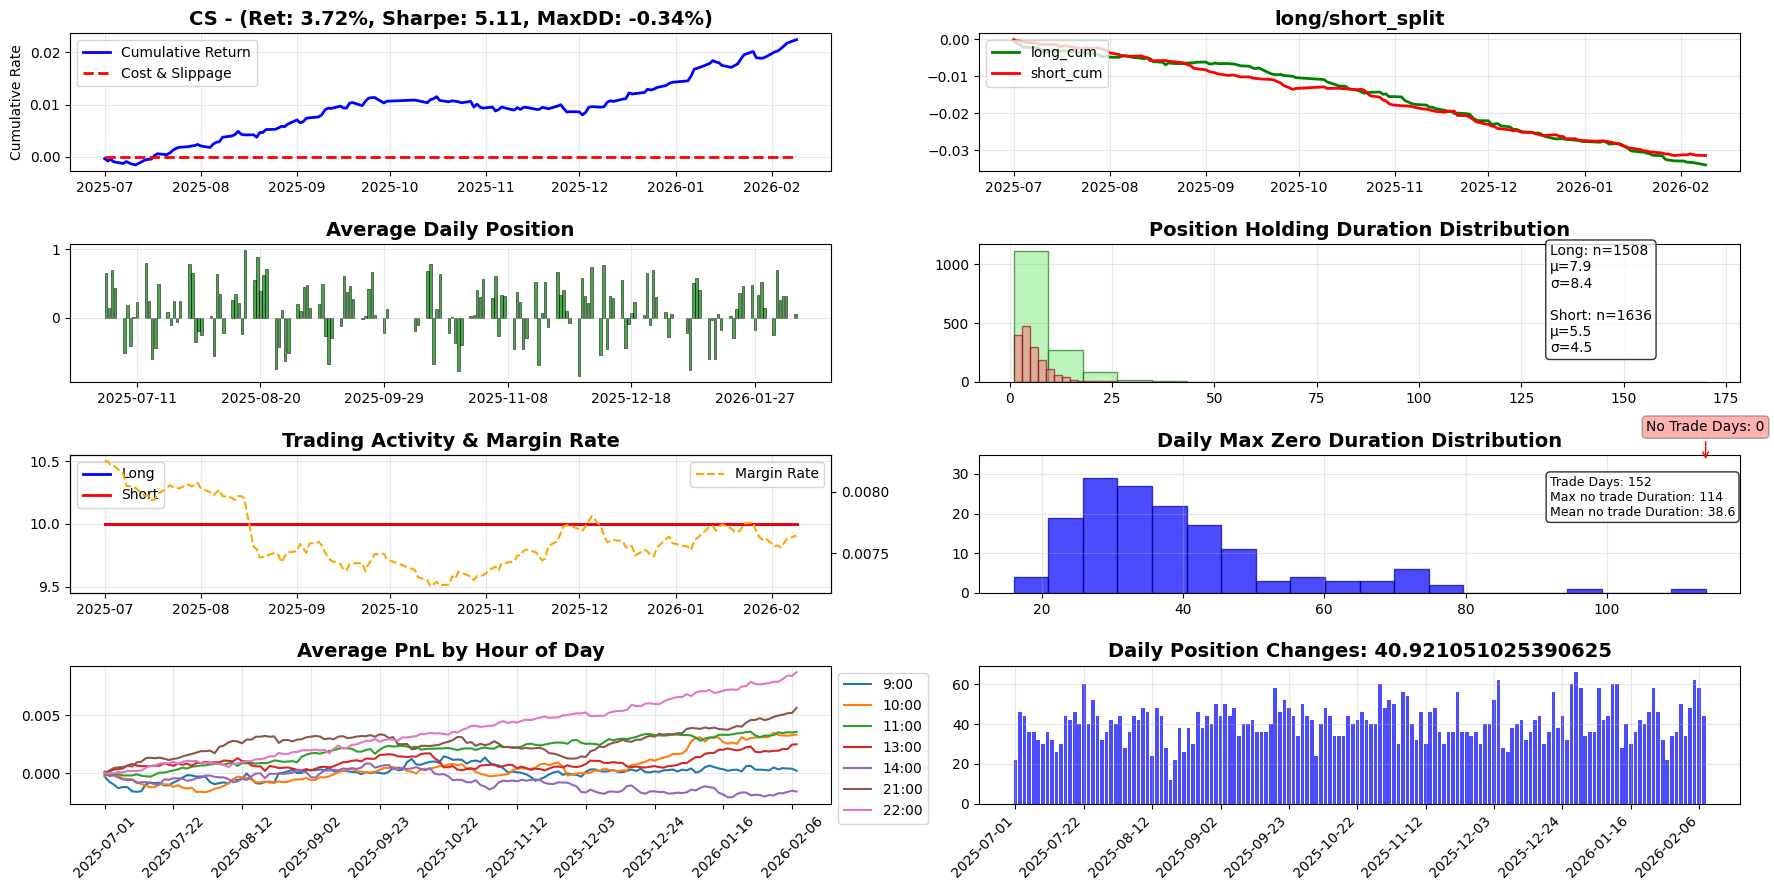

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: CS
📅 总交易日数: 152
📊 总数据点: 55176
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)